In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [10]:
patients=pd.read_csv("Hospital_Patients.csv")
visits=pd.read_csv("Hospital_Visits.csv")
billings=pd.read_csv("Hospital_Billing.csv")

In [11]:
print("patients dataset",patients.head())
print("visits dataset",visits.head())
print("billing dataset",billings.head())

patients dataset   Patient_ID   Patient_Name   Age  Gender Blood_Group       City  \
0      P1001  Vivaan Mistry  72.0  Female          O-     Mumbai   
1      P1002    Aanya Joshi  66.0    Male          A+  Ahmedabad   
2      P1003     Dev Parikh  50.0       F          B-       Pune   
3      P1004  Vivaan Gandhi  79.0    Male          B-  Ahmedabad   
4      P1005    Rohan Patel  12.0  Female          O+  Ahmedabad   

  Registration_Date Insurance_Status Chronic_Condition Patient_Type  
0        2025-10-11          Insured     Heart Disease          New  
1        2025-09-03          Insured            Asthma    Returning  
2        2025-12-06      Not Insured               NaN    Returning  
3        2025-12-17      Not Insured     Heart Disease    Returning  
4        2025-09-15          Insured          Diabetes          New  
visits dataset   Visit_ID Patient_ID   Department      Doctor  Visit_Date Visit_Type  \
0    V2001      P1373          ENT    Dr. Vyas  2025-09-30  Follow

In [12]:
print("missing patient id:",patients["Patient_ID"].isnull().sum())
print("missing age:",patients["Age"].isnull().sum())
print("missing billing mode:",billings["Payment_Mode"].isnull().sum())

missing patient id: 0
missing age: 8
missing billing mode: 6


In [13]:
patients.dropna(subset=["Patient_ID"],inplace=True)

In [14]:
patients["Age"]=patients["Age"].fillna(patients["Age"].median())

In [15]:
billings["Payment_Mode"]=billings["Payment_Mode"].fillna(billings["Payment_Mode"].mode()[0])

In [16]:
print("patients duplicated record:",patients.duplicated().sum())
print("billing duplicated record:",billings.duplicated().sum())

patients duplicated record: 0
billing duplicated record: 0


In [17]:
print("missing value after cleaning:")
print("patient id:",patients["Patient_ID"].isnull().sum())
print("patients age:",patients["Age"].isnull().sum())
print("billing mode:",billings["Payment_Mode"].isnull().sum())

print("duplicated patients record:",patients.duplicated().sum())
print("duplicated billing record:",billings.duplicated().sum())

missing value after cleaning:
patient id: 0
patients age: 0
billing mode: 0
duplicated patients record: 0
duplicated billing record: 0


In [18]:
print("gender values:",patients["Gender"].unique())
print("city values:",patients["City"].unique())
print("visit type values:",visits["Visit_Type"].unique())
print("admission values:",visits["Admission_Status"].unique())

gender values: ['Female' 'Male' 'F' nan 'male' ' FEMALE ' 'M']
city values: ['Mumbai' 'Ahmedabad' 'Pune' 'Rajkot' 'Gandhinagar' 'Surat' 'Nashik'
 'Vadodara' nan 'VADODARA' ' Surat ' 'ahmedabad' 'mumbai ']
visit type values: ['Follow-up' 'OPD' 'Emergency' 'Diagnostic' 'opd' 'Follow up' 'emergency'
 'follow-up' ' OPD ']
admission values: ['Admitted' 'Discharged' 'Outpatient' 'out patient' 'DISCHARGED'
 'Out-Patient' 'admitted']


In [19]:
patients["Gender"]=(patients["Gender"].astype("string").str.strip().str.title())
patients["Gender"]=patients["Gender"].replace({
    "F":"Female","M":"Male"})
patients["City"]=(patients["City"].astype("string").str.strip().str.title())
visits["Visit_Type"]=(visits["Visit_Type"].astype("string").str.strip().str.title())
visits["Visit_Type"]=visits["Visit_Type"].replace({
    "follow-up":"Follow-up","Follow up":"Follow-up","opd":"OPD","emergency":"Emergency"})
visits["Admission_Status"]=(visits["Admission_Status"].astype("string").str.strip().str.title())
visits["Admission_Status"]=visits["Admission_Status"].replace({
    "admitted":"Admitted","DISCHARGED":"Discharged","Outpatient":"Out-patient",
    "out patient":"Out-patient"
})

In [20]:
print("gender values:",patients["Gender"].unique())
print("city values:",patients["City"].unique())
print("visit type values:",visits["Visit_Type"].unique())
print("admission values:",visits["Admission_Status"].unique())

gender values: <StringArray>
['Female', 'Male', <NA>]
Length: 3, dtype: string
city values: <StringArray>
[     'Mumbai',   'Ahmedabad',        'Pune',      'Rajkot', 'Gandhinagar',
       'Surat',      'Nashik',    'Vadodara',          <NA>]
Length: 9, dtype: string
visit type values: <StringArray>
['Follow-Up', 'Opd', 'Emergency', 'Diagnostic', 'Follow Up']
Length: 5, dtype: string
admission values: <StringArray>
['Admitted', 'Discharged', 'Out-patient', 'Out Patient', 'Out-Patient']
Length: 5, dtype: string


In [21]:
#3

In [22]:
print("abnormal age value:")
print(patients[(patients["Age"]<0)|(patients["Age"]>120)])
print("abnormal length of stay values:")
print(visits[visits["Length_of_Stay_Days"]<0])
print("abnormal satisfication score value:")
print(visits[(visits["Satisfaction_Score"]<1)|
    (visits["Satisfaction_Score"]>5)])

abnormal age value:
    Patient_ID  Patient_Name    Age  Gender Blood_Group    City  \
34       P1035  Vivaan Joshi  145.0  Female          O-    Pune   
48       P1049  Rohan Gandhi   -4.0    Male          O+  Rajkot   
361      P1362    Nisha Shah  121.0    Male          O+  Nashik   
405      P1406  Aarav Parikh  121.0    Male          O+    Pune   

    Registration_Date Insurance_Status Chronic_Condition Patient_Type  
34         2025-02-06          Insured          Diabetes    Returning  
48         2025-03-03          Insured            Asthma          New  
361        2025-09-29          Insured               NaN          New  
405        2025-05-09      Not Insured     Heart Disease    Returning  
abnormal length of stay values:
    Visit_ID Patient_ID        Department     Doctor  Visit_Date  Visit_Type  \
352    V2353      P1421  General Medicine  Dr. Desai  2025-10-21         Opd   
432    V2433      P1043        Pediatrics  Dr. Patel  2025-04-10  Diagnostic   

     Length

In [26]:
import numpy as np
patients.loc[(patients["Age"]<0)|(patients["Age"]>120),"Age"]=np.nan
patients["Age"]=patients["Age"].fillna(patients["Age"].median())

visits.loc[visits["Length_of_Stay_Days"]<0,"Length_of_Stay_Days"]=np.nan
visits["Length_of_Stay_Days"]=visits["Length_of_Stay_Days"].fillna(visits["Length_of_Stay_Days"].median())

visits.loc[(visits["Satisfaction_Score"]<1)|(visits["Satisfaction_Score"]>5),"Satisfaction_score"]=np.nan
visits["Satisfaction_Score"]=visits["Satisfaction_score"].fillna(visits["Satisfaction_Score"].median())


In [28]:
print("age range:",patients["Age"].min(),patients["Age"].max())
print("length of the range:",visits["Length_of_Stay_Days"].min(),visits["Length_of_Stay_Days"].max())
print("Satisfaction score range:",visits["Satisfaction_Score"].min(),visits["Satisfaction_Score"].max())

age range: 0.0 89.0
length of the range: 0.0 120.0
Satisfaction score range: 3.0 3.0


In [31]:
print("missing billing value:")
print(billings[["Room_Charges","Total_Bill","Insurance_Coverage","Net_Amount"]].isnull().sum())
print("negative billing value:")
print(billings[(billings["Room_Charges"]<0)|
                (billings["Total_Bill"]<0)|
                (billings["Insurance_Coverage"]<0)|
                (billings["Net_Amount"]<0)
    ])

missing billing value:
Room_Charges          7
Total_Bill            0
Insurance_Coverage    7
Net_Amount            0
dtype: int64
negative billing value:
    Bill_ID Visit_ID Patient_ID  Room_Charges  Medicine_Charges  Lab_Charges  \
81    B3082    V2037      P1442       -500.00          13548.94      5846.84   
277   B3278    V2169      P1139       7735.39           1408.70      7709.34   
303   B3304    V2004      P1421      11431.47          13097.86      6772.22   
443   B3444    V2136      P1410      10480.49           5369.41      3650.46   

     Other_Charges  Insurance_Coverage Payment_Mode Payment_Status  \
81         2905.57                 NaN          UPI           Paid   
277        1822.38             -1000.0    Insurance        Pending   
303        3106.74             -1000.0         Cash           Paid   
443        4809.58             -1000.0         Cash        Pending   

      Bill_Date  Total_Bill  Net_Amount  
81   2025-03-09    30356.72    27480.59  
277  202

In [33]:
billings["Expected_Net_Amount"]=(billings["Total_Bill"]-billings["Insurance_Coverage"])
print("incorrect net amount record:",billings["Net_Amount"]!=billings["Expected_Net_Amount"])

incorrect net amount record: 0       True
1      False
2      False
3      False
4       True
       ...  
495    False
496     True
497    False
498     True
499     True
Length: 500, dtype: bool


In [35]:
columns=["Room_Charges","Total_Bill","Insurance_Coverage","Net_Amount"]
for col in columns:
    billings.loc[billings[col]<0,col]=np.nan
billings["Net_Amount"]=(billings["Total_Bill"]-billings["Insurance_Coverage"])


In [37]:
print("invalid insurance coverage:")
print(billings[billings["Insurance_Coverage"]>billings["Total_Bill"]])

invalid insurance coverage:
    Bill_ID Visit_ID Patient_ID  Room_Charges  Medicine_Charges  Lab_Charges  \
10    B3011    V2412      P1353       6034.73           7230.43       172.95   
18    B3019    V2002      P1392       1928.75          12023.75      7193.11   
22    B3023    V2022      P1048       9146.76           1781.46      3637.82   
28    B3029    V2499      P1384       7941.11           4257.21      5009.96   
32    B3033    V2097      P1478       2258.70           5077.25      1457.43   
..      ...      ...        ...           ...               ...          ...   
470   B3471    V2499      P1142       2012.29          13778.04      1244.93   
472   B3473    V2306      P1252       8254.64           5854.72       620.58   
478   B3479    V2178      P1178       3443.57           2076.44      4037.66   
481   B3482    V2258      P1242       7367.35           1727.73      4510.32   
499   B3500    V2098      P1300        513.96           6558.89      4809.12   

     Other_

In [38]:
print(billings[[
    "Room_Charges",
    "Total_Bill",
    "Insurance_Coverage",
    "Net_Amount"
]].head())

print("\nMissing Values:")
print(billings[columns].isnull().sum())

   Room_Charges  Total_Bill  Insurance_Coverage  Net_Amount
0       2128.00    21993.02                 NaN         NaN
1       9767.65    21720.84             2425.18    19295.66
2       4241.70    21624.10              484.23    21139.87
3       5530.28     6395.55             2060.37     4335.18
4       4647.68    22746.18             9121.71    13624.47

Missing Values:
Room_Charges           8
Total_Bill             0
Insurance_Coverage    10
Net_Amount            10
dtype: int64


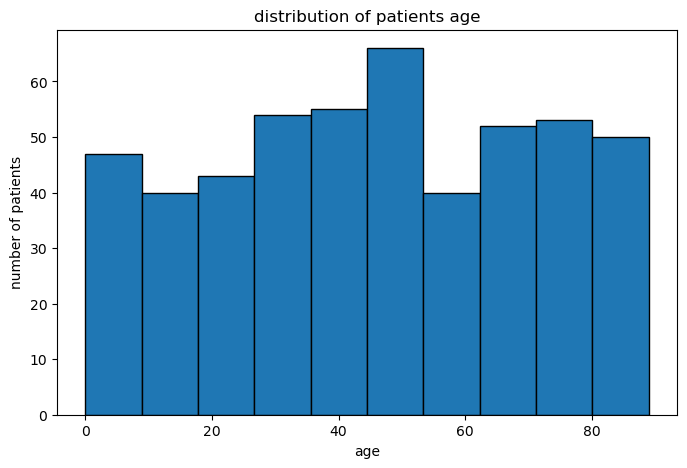

In [40]:
plt.figure(figsize=(8,5))
plt.hist(patients["Age"].dropna(),bins=10,edgecolor="black")
plt.title("distribution of patients age")
plt.xlabel("age")
plt.ylabel("number of patients")
plt.show()

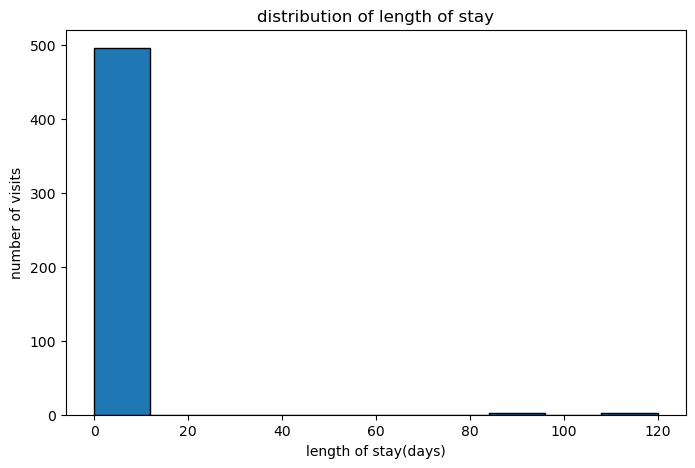

In [42]:
plt.figure(figsize=(8,5))
plt.hist(visits["Length_of_Stay_Days"].dropna(),bins=10,edgecolor="black")
plt.title("distribution of length of stay")
plt.xlabel("length of stay(days)")
plt.ylabel("number of visits")
plt.show()

AttributeError: module 'matplotlib.pyplot' has no attribute 'xtricks'

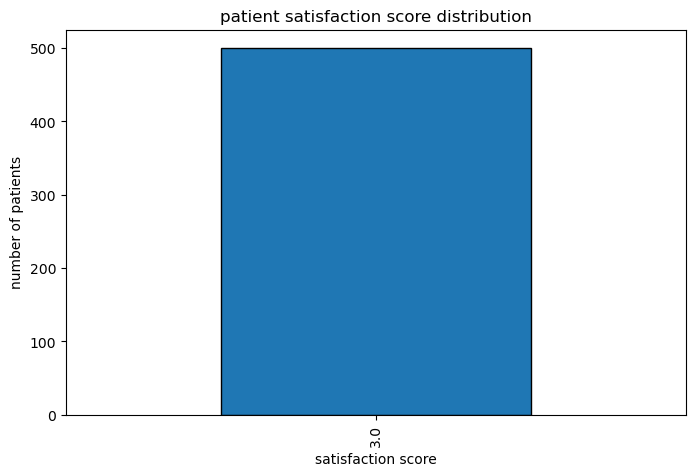

In [46]:
plt.figure(figsize=(8,5))
visits["Satisfaction_Score"].value_counts().sort_index().plot(kind="bar",edgecolor="black")
plt.title("patient satisfaction score distribution")
plt.xlabel("satisfaction score")
plt.ylabel("number of patients")
plt.xtricks(rotation=0)
plt.show()

In [45]:
print(visits.columns.tolist())

['Visit_ID', 'Patient_ID', 'Department', 'Doctor', 'Visit_Date', 'Visit_Type', 'Length_of_Stay_Days', 'Treatment_Cost', 'Consultation_Fee', 'Admission_Status', 'Outcome', 'Satisfaction_Score', 'Satisfaction_score']


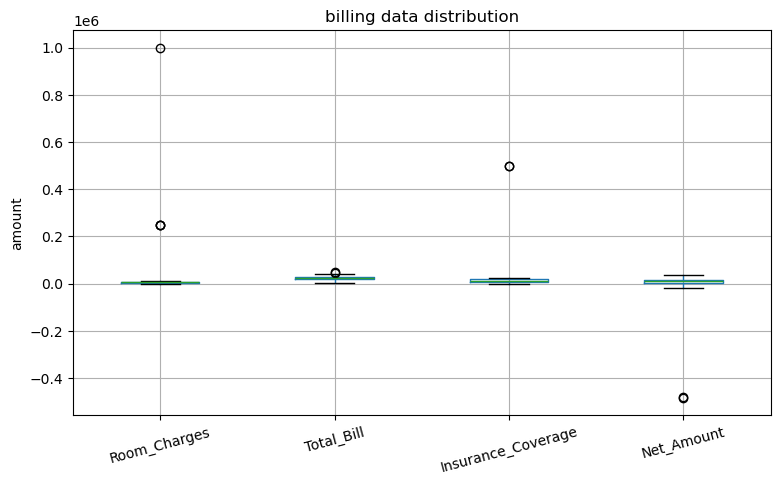

In [50]:
plt.figure(figsize=(9,5))
billings[["Room_Charges","Total_Bill","Insurance_Coverage","Net_Amount"]].boxplot()
plt.title("billing data distribution")
plt.ylabel("amount")
plt.xticks(rotation=15)
plt.show()

In [51]:
patients.to_csv("patients_clean.csv",index=False)
billings.to_csv("billings_clean.csv",index=False)
visits.to_csv("visitors_clean.csv",index=False)